In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split

In [3]:
from sklearn.ensemble import IsolationForest
from sklearn.ensemble import IsolationForest

In [4]:
df=pd.read_csv('embedded_system_network_security_dataset.csv')
df.head()


,packet_size,inter_arrival_time,src_port,dst_port,packet_count_5s,mean_packet_size,spectral_entropy,frequency_band_energy,label,protocol_type_TCP,protocol_type_UDP,src_ip_192.168.1.2,src_ip_192.168.1.3,dst_ip_192.168.1.5,dst_ip_192.168.1.6,tcp_flags_FIN,tcp_flags_SYN,tcp_flags_SYN-ACK
0,0.405154,0.620362,62569,443,0.857143,0.0,0.834066,0.534891,0.0,False,True,True,False,False,False,False,False,False
1,0.527559,0.741288,59382,443,0.785714,0.0,0.147196,0.990757,0.0,False,True,False,False,False,True,False,True,False
2,0.226199,0.485116,65484,80,0.285714,0.0,0.855192,0.031781,0.0,False,True,False,False,True,False,False,False,False
3,0.573372,0.450965,51707,53,0.142857,0.0,0.153220,0.169958,0.0,False,False,False,True,False,False,False,False,False
4,0.651396,0.888740,26915,53,0.714286,0.0,0.923916,0.552053,0.0,True,False,False,True,False,False,False,True,False


In [5]:
df.isnull().sum()

packet_size              0
inter_arrival_time       0
src_port                 0
dst_port                 0
packet_count_5s          0
mean_packet_size         0
spectral_entropy         0
frequency_band_energy    0
label                    0
protocol_type_TCP        0
protocol_type_UDP        0
src_ip_192.168.1.2       0
src_ip_192.168.1.3       0
dst_ip_192.168.1.5       0
dst_ip_192.168.1.6       0
tcp_flags_FIN            0
tcp_flags_SYN            0
tcp_flags_SYN-ACK        0
dtype: int64

In [6]:
# drop the label column if exists
features=df.drop('label',axis=1)
features

,packet_size,inter_arrival_time,src_port,dst_port,packet_count_5s,mean_packet_size,spectral_entropy,frequency_band_energy,protocol_type_TCP,protocol_type_UDP,src_ip_192.168.1.2,src_ip_192.168.1.3,dst_ip_192.168.1.5,dst_ip_192.168.1.6,tcp_flags_FIN,tcp_flags_SYN,tcp_flags_SYN-ACK
0,0.405154,0.620362,62569,443,0.857143,0.0,0.834066,0.534891,False,True,True,False,False,False,False,False,False
1,0.527559,0.741288,59382,443,0.785714,0.0,0.147196,0.990757,False,True,False,False,False,True,False,True,False
2,0.226199,0.485116,65484,80,0.285714,0.0,0.855192,0.031781,False,True,False,False,True,False,False,False,False
3,0.573372,0.450965,51707,53,0.142857,0.0,0.153220,0.169958,False,False,False,True,False,False,False,False,False
4,0.651396,0.888740,26915,53,0.714286,0.0,0.923916,0.552053,True,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.103794,0.078032,26435,443,0.428571,0.0,0.339083,0.402062,False,True,False,False,True,False,False,True,False
996,0.727989,0.048901,49767,80,0.928571,0.0,0.094822,0.418902,False,False,False,True,True,False,False,False,True
997,0.952756,0.731936,53507,80,0.928571,0.0,0.016880,0.441276,False,True,False,True,True,False,False,False,False
998,0.322835,0.655933,17255,53,0.071429,0.0,0.887533,0.806790,False,False,False,True,False,True,False,False,True


In [7]:

for col in features.columns:
    if features[col].dtype=='bool':
        features[col]=features[col].astype(int)


In [8]:

features.dtypes

packet_size              float64
inter_arrival_time       float64
src_port                   int64
dst_port                   int64
packet_count_5s          float64
mean_packet_size         float64
spectral_entropy         float64
frequency_band_energy    float64
protocol_type_TCP          int64
protocol_type_UDP          int64
src_ip_192.168.1.2         int64
src_ip_192.168.1.3         int64
dst_ip_192.168.1.5         int64
dst_ip_192.168.1.6         int64
tcp_flags_FIN              int64
tcp_flags_SYN              int64
tcp_flags_SYN-ACK          int64
dtype: object

In [9]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaler_features=scaler.fit_transform(features)
scaler_features

array([[-0.33611459,  0.38472447,  1.65001067, ..., -0.57888987,
        -0.55424682, -0.58504861],
       [ 0.08675815,  0.81508034,  1.4778486 , ..., -0.57888987,
         1.8042503 , -0.58504861],
       [-0.95434959, -0.09659806,  1.80747926, ..., -0.57888987,
        -0.55424682, -0.58504861],
       ...,
       [ 1.55568452,  0.78180053,  1.16048051, ..., -0.57888987,
        -0.55424682, -0.58504861],
       [-0.62050269,  0.51131651, -0.79785621, ..., -0.57888987,
        -0.55424682,  1.70925967],
       [-1.12498245, -1.16074428, -1.31931225, ..., -0.57888987,
         1.8042503 , -0.58504861]], shape=(1000, 17))

In [10]:
scaled_features_df = pd.DataFrame(scaler_features, columns=features.columns)
scaled_features_df.head()


,packet_size,inter_arrival_time,src_port,dst_port,packet_count_5s,mean_packet_size,spectral_entropy,frequency_band_energy,protocol_type_TCP,protocol_type_UDP,src_ip_192.168.1.2,src_ip_192.168.1.3,dst_ip_192.168.1.5,dst_ip_192.168.1.6,tcp_flags_FIN,tcp_flags_SYN,tcp_flags_SYN-ACK
0,-0.336115,0.384724,1.650011,1.351370,1.155602,0.0,1.157333,0.166460,-0.671847,1.347925,1.471243,-0.714545,-0.712949,-0.722544,-0.57889,-0.554247,-0.585049
1,0.086758,0.815080,1.477849,1.351370,0.919957,0.0,-1.188696,1.707564,-0.671847,1.347925,-0.679697,-0.714545,-0.712949,1.383999,-0.57889,1.804250,-0.585049
2,-0.954350,-0.096598,1.807479,-0.665426,-0.729556,0.0,1.229489,-1.534356,-0.671847,1.347925,-0.679697,-0.714545,1.402626,-0.722544,-0.57889,-0.554247,-0.585049
3,0.245026,-0.218135,1.063244,-0.815436,-1.200846,0.0,-1.168120,-1.067234,-0.671847,-0.741881,-0.679697,1.399493,-0.712949,-0.722544,-0.57889,-0.554247,-0.585049
4,0.514577,1.339842,-0.276022,-0.815436,0.684312,0.0,1.464215,0.224480,1.488433,-0.741881,-0.679697,1.399493,-0.712949,-0.722544,-0.57889,1.804250,-0.585049


In [11]:

# parameters for isolation forest
n_estimators=100 #no of trees in forest
contamination=0.01 
sample_size=256


In [12]:

model=IsolationForest(n_estimators=n_estimators,contamination=contamination,
                      max_samples=sample_size,random_state=42)
model.fit(features)
anomaly_labels=model.predict(features)
# -1 for anomalies ,1 for normal
anomaly_labels

array([ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1, -1,  1,  1

In [13]:
features['anomaly']=anomaly_labels
features.head()

,packet_size,inter_arrival_time,src_port,dst_port,packet_count_5s,mean_packet_size,spectral_entropy,frequency_band_energy,protocol_type_TCP,protocol_type_UDP,src_ip_192.168.1.2,src_ip_192.168.1.3,dst_ip_192.168.1.5,dst_ip_192.168.1.6,tcp_flags_FIN,tcp_flags_SYN,tcp_flags_SYN-ACK,anomaly
0,0.405154,0.620362,62569,443,0.857143,0.0,0.834066,0.534891,0,1,1,0,0,0,0,0,0,1
1,0.527559,0.741288,59382,443,0.785714,0.0,0.147196,0.990757,0,1,0,0,0,1,0,1,0,1
2,0.226199,0.485116,65484,80,0.285714,0.0,0.855192,0.031781,0,1,0,0,1,0,0,0,0,1
3,0.573372,0.450965,51707,53,0.142857,0.0,0.153220,0.169958,0,0,0,1,0,0,0,0,0,1
4,0.651396,0.888740,26915,53,0.714286,0.0,0.923916,0.552053,1,0,0,1,0,0,0,1,0,1


In [14]:
features['anomaly'].value_counts()



anomaly
 1    990
-1     10
Name: count, dtype: int64

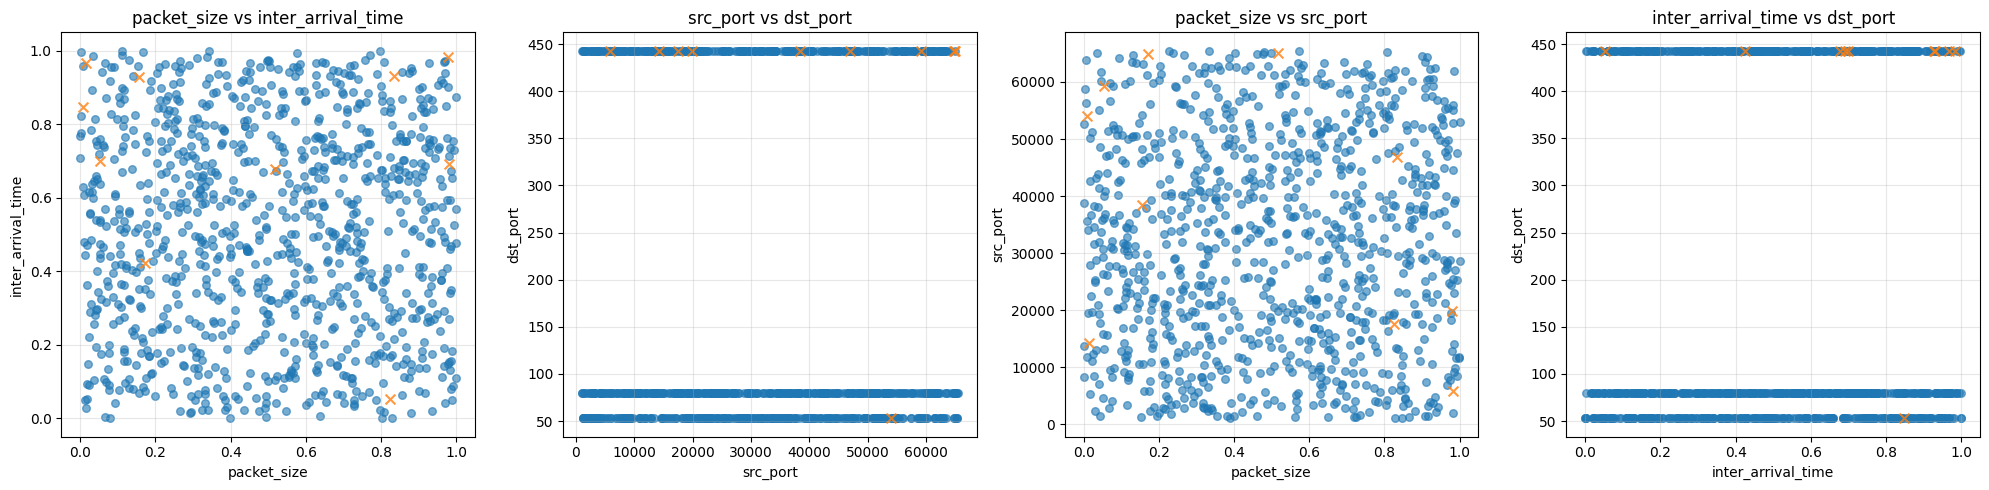

Normal data points: 990
Anomalies detected: 10


In [20]:

import matplotlib.pyplot as plt

# Create 1 row, 4 columns
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

normal = features[features['anomaly'] == 1]
anomaly = features[features['anomaly'] == -1]

# Plot 1: packet_size vs inter_arrival_time
axes[0].scatter(normal['packet_size'], normal['inter_arrival_time'], alpha=0.6, s=30)
axes[0].scatter(anomaly['packet_size'], anomaly['inter_arrival_time'], alpha=0.8, s=50, marker='x')
axes[0].set_xlabel('packet_size')
axes[0].set_ylabel('inter_arrival_time')
axes[0].set_title('packet_size vs inter_arrival_time')
axes[0].grid(True, alpha=0.3)

# Plot 2: src_port vs dst_port
axes[1].scatter(normal['src_port'], normal['dst_port'], alpha=0.6, s=30)
axes[1].scatter(anomaly['src_port'], anomaly['dst_port'], alpha=0.8, s=50, marker='x')
axes[1].set_xlabel('src_port')
axes[1].set_ylabel('dst_port')
axes[1].set_title('src_port vs dst_port')
axes[1].grid(True, alpha=0.3)

# Plot 3: packet_size vs src_port
axes[2].scatter(normal['packet_size'], normal['src_port'], alpha=0.6, s=30)
axes[2].scatter(anomaly['packet_size'], anomaly['src_port'], alpha=0.8, s=50, marker='x')
axes[2].set_xlabel('packet_size')
axes[2].set_ylabel('src_port')
axes[2].set_title('packet_size vs src_port')
axes[2].grid(True, alpha=0.3)

# Plot 4: inter_arrival_time vs dst_port
axes[3].scatter(normal['inter_arrival_time'], normal['dst_port'], alpha=0.6, s=30)
axes[3].scatter(anomaly['inter_arrival_time'], anomaly['dst_port'], alpha=0.8, s=50, marker='x')
axes[3].set_xlabel('inter_arrival_time')
axes[3].set_ylabel('dst_port')
axes[3].set_title('inter_arrival_time vs dst_port')
axes[3].grid(True, alpha=0.3) 

plt.tight_layout()
plt.show()

print(f"Normal data points: {len(normal)}")
print(f"Anomalies detected: {len(anomaly)}")
